In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.cluster import KMeans
from pyproj import Transformer
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import RobustScaler
from pyproj import Transformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import plotly.express as px

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
pd.options.display.float_format = "{:,.1f}".format


In [37]:
df = pd.read_parquet("df_preprocessed.parquet")


In [3]:

# unified price
df['unified_price'] = np.where(
    df['price_value'].notna(),
    df['price_value'],
    df['effective_rent'] * (1_000_000 / 30_000) * 6
)


In [4]:

def impute_building_size_all_categories(df_input):
  
    df = df_input.copy()

    size_bounds = {
        'apartment-sell': (15, 700),
        'apartment-rent': (15, 700),
        'house-villa-sell': (30, 2000),
        'house-villa-rent': (30, 2000),
        'plot-old': (50, 100000),
        'shop-rent': (5, 3000),
        'shop-sell': (5, 3000),
        'office-rent': (10, 2000),
        'office-sell': (10, 2000),
        'industry-agriculture-business-rent': (50, 500000),
        'industry-agriculture-business-sell': (50, 500000),
    }

    df['building_size_imputed_all'] = df['building_size']
    df['price_per_sqm_raw'] = np.nan

    valid_ppsqm_mask = (
        df['unified_price'].notna() & (df['unified_price'] > 0) &
        df['building_size'].notna() & (df['building_size'] > 0)
    )
    df.loc[valid_ppsqm_mask, 'price_per_sqm_raw'] = (
        df.loc[valid_ppsqm_mask, 'unified_price'] / df.loc[valid_ppsqm_mask, 'building_size']
    )

    summary = []

    for cat, (min_size, max_size) in size_bounds.items():
        cat_mask = df['cat3_slug'] == cat

        outlier_mask = cat_mask & (
            df['building_size'].isna() |
            (df['building_size'] < min_size) |
            (df['building_size'] > max_size)
        )

        healthy_mask = cat_mask & (
            df['building_size'].notna() &
            (df['building_size'] >= min_size) &
            (df['building_size'] <= max_size) &
            df['unified_price'].notna() & (df['unified_price'] > 0)
        )

        neighborhood_ppsqm = (
            df.loc[healthy_mask]
            .groupby('neighborhood_slug')['price_per_sqm_raw']
            .median()
        )

        cat_ppsqm = df.loc[healthy_mask, 'price_per_sqm_raw'].median()

        neighborhood_size = (
            df.loc[cat_mask & df['building_size'].notna() &
                   (df['building_size'] >= min_size) & (df['building_size'] <= max_size)]
            .groupby('neighborhood_slug')['building_size']
            .median()
        )

        cat_size = df.loc[
            cat_mask & df['building_size'].notna() &
            (df['building_size'] >= min_size) & (df['building_size'] <= max_size),
            'building_size'
        ].median()

        outlier_indices = df.loc[outlier_mask].index
        fixed_by_price = 0
        fixed_by_neigh_size = 0
        fixed_by_cat_size = 0

        for idx in outlier_indices:
            row = df.loc[idx]
            neigh = row.get('neighborhood_slug', np.nan)
            price = row.get('unified_price', np.nan)
            new_size = np.nan

            if pd.notna(price) and price > 0:
                med_ppsqm = neighborhood_ppsqm.get(neigh, np.nan)
                if pd.isna(med_ppsqm) or med_ppsqm <= 0:
                    med_ppsqm = cat_ppsqm

                if pd.notna(med_ppsqm) and med_ppsqm > 0:
                    new_size = price / med_ppsqm
                    new_size = np.clip(new_size, min_size, max_size)
                    fixed_by_price += 1

            if pd.isna(new_size):
                med_size_neigh = neighborhood_size.get(neigh, np.nan)
                if pd.notna(med_size_neigh):
                    new_size = med_size_neigh
                    fixed_by_neigh_size += 1

            if pd.isna(new_size):
                new_size = cat_size
                fixed_by_cat_size += 1

            df.at[idx, 'building_size_imputed_all'] = new_size

        summary.append({
            'Category': cat,
            'Total Rows': int(cat_mask.sum()),
            'Outliers Detected': int(outlier_mask.sum()),
            'Fixed by Price': fixed_by_price,
            'Fixed by Neighborhood Size': fixed_by_neigh_size,
            'Fixed by Category Size': fixed_by_cat_size,
        })

    return df, pd.DataFrame(summary).sort_values('Outliers Detected', ascending=False)


In [5]:


def impute_unified_price_all_categories(df_input):

    df = df_input.copy()

    if 'building_size_imputed_all' not in df.columns:
        raise ValueError(" run (impute_building_size_all_categories)")

    ppsqm_bounds = {
        'apartment-sell': (1_000_000, 500_000_000),
        'apartment-rent': (1_000_000, 500_000_000), 
        'house-villa-sell': (500_000, 500_000_000),
        'house-villa-rent': (500_000, 500_000_000),
        'plot-old': (100_000, 300_000_000),
        'shop-rent': (500_000, 1_000_000_000),
        'shop-sell': (500_000, 1_000_000_000),
        'office-rent': (500_000, 500_000_000),
        'office-sell': (500_000, 500_000_000),
        'industry-agriculture-business-rent': (50_000, 200_000_000),
        'industry-agriculture-business-sell': (50_000, 200_000_000),
    }

    df['price_per_sqm_imputed_base'] = np.nan
    valid_mask = (
        df['unified_price'].notna() & (df['unified_price'] > 0) &
        df['building_size_imputed_all'].notna() & (df['building_size_imputed_all'] > 0)
    )
    df.loc[valid_mask, 'price_per_sqm_imputed_base'] = (
        df.loc[valid_mask, 'unified_price'] / df.loc[valid_mask, 'building_size_imputed_all']
    )

    df['unified_price_imputed_all'] = df['unified_price']
    summary = []

    for cat, (min_ppsqm, max_ppsqm) in ppsqm_bounds.items():
        cat_mask = df['cat3_slug'] == cat

        invalid_price_mask = cat_mask & (
            df['unified_price'].isna() |
            (df['unified_price'] <= 0) |
            df['building_size_imputed_all'].isna() |
            (df['building_size_imputed_all'] <= 0) |
            df['price_per_sqm_imputed_base'].isna() |
            (df['price_per_sqm_imputed_base'] < min_ppsqm) |
            (df['price_per_sqm_imputed_base'] > max_ppsqm)
        )

        healthy_mask = cat_mask & (
            df['unified_price'].notna() & (df['unified_price'] > 0) &
            df['building_size_imputed_all'].notna() & (df['building_size_imputed_all'] > 0) &
            df['price_per_sqm_imputed_base'].notna() &
            (df['price_per_sqm_imputed_base'] >= min_ppsqm) &
            (df['price_per_sqm_imputed_base'] <= max_ppsqm)
        )

        neighborhood_ppsqm = (
            df.loc[healthy_mask]
            .groupby('neighborhood_slug')['price_per_sqm_imputed_base']
            .median()
        )

        cat_ppsqm = df.loc[healthy_mask, 'price_per_sqm_imputed_base'].median()

        outlier_indices = df.loc[invalid_price_mask].index
        fixed_by_neighborhood = 0
        fixed_by_category = 0

        for idx in outlier_indices:
            row = df.loc[idx]
            neigh = row.get('neighborhood_slug', np.nan)
            size_val = row.get('building_size_imputed_all', np.nan)

            if pd.isna(size_val) or size_val <= 0:
                continue

            med_ppsqm = neighborhood_ppsqm.get(neigh, np.nan)

            if pd.notna(med_ppsqm) and med_ppsqm > 0:
                df.at[idx, 'unified_price_imputed_all'] = size_val * med_ppsqm
                fixed_by_neighborhood += 1
            elif pd.notna(cat_ppsqm) and cat_ppsqm > 0:
                df.at[idx, 'unified_price_imputed_all'] = size_val * cat_ppsqm
                fixed_by_category += 1

        summary.append({
            'Category': cat,
            'Total Rows': int(cat_mask.sum()),
            'Invalid Prices Detected': int(invalid_price_mask.sum()),
            'Fixed by Neighborhood Price': fixed_by_neighborhood,
            'Fixed by Category Price': fixed_by_category,
        })

    return df, pd.DataFrame(summary).sort_values('Invalid Prices Detected', ascending=False)


In [6]:

df_size_fixed, size_report = impute_building_size_all_categories(df)


In [7]:

df_final, price_report = impute_unified_price_all_categories(df_size_fixed)


In [25]:

df = df_final.copy()

size_bounds = {
    'apartment-sell': (15, 700),
    'apartment-rent': (15, 700),
    'house-villa-sell': (30, 2000),
    'house-villa-rent': (30, 2000),
    'plot-old': (50, 100000),
    'shop-rent': (5, 3000),
    'shop-sell': (5, 3000),
    'office-rent': (10, 2000),
    'office-sell': (10, 2000),
    'industry-agriculture-business-rent': (50, 500000),
    'industry-agriculture-business-sell': (50, 500000),
}

ppsqm_bounds = {
    'apartment-sell': (1_000_000, 5_000_000_000),
    'apartment-rent': (1_000_000, 5_000_000_000),
    'house-villa-sell': (500_000, 5_000_000_000),
    'house-villa-rent': (500_000, 5_000_000_000),
    'plot-old': (100_000, 3_000_000_000),
    'shop-rent': (500_000, 5_000_000_000),
    'shop-sell': (500_000, 5_000_000_000),
    'office-rent': (500_000, 5_000_000_000),
    'office-sell': (500_000, 5_000_000_000),
    'industry-agriculture-business-rent': (50_000, 2_000_000_000),
    'industry-agriculture-business-sell': (50_000, 2_000_000_000),
}

df['ppsqm_final'] = df['unified_price_imputed_all'] / df['building_size_imputed_all']

size_rows = []
price_rows = []

for cat, (min_size, max_size) in size_bounds.items():
    cat_mask = df['cat3_slug'] == cat
    size_outlier_mask = cat_mask & (
        df['building_size_imputed_all'].isna() |
        (df['building_size_imputed_all'] < min_size) |
        (df['building_size_imputed_all'] > max_size)
    )
    size_rows.append({
        'cat3_slug': cat,
        'total_rows': int(cat_mask.sum()),
        'size_outliers': int(size_outlier_mask.sum()),
        'size_outlier_pct': round(100 * size_outlier_mask.mean(), 3) if cat_mask.sum() > 0 else 0
    })

for cat, (min_ppsqm, max_ppsqm) in ppsqm_bounds.items():
    cat_mask = df['cat3_slug'] == cat
    price_outlier_mask = cat_mask & (
        df['unified_price_imputed_all'].isna() |
        (df['unified_price_imputed_all'] <= 0) |
        df['ppsqm_final'].isna() |
        (df['ppsqm_final'] < min_ppsqm) |
        (df['ppsqm_final'] > max_ppsqm)
    )
    price_rows.append({
        'cat3_slug': cat,
        'total_rows': int(cat_mask.sum()),
        'price_outliers': int(price_outlier_mask.sum()),
        'price_outlier_pct': round(100 * price_outlier_mask.mean(), 3) if cat_mask.sum() > 0 else 0
    })

size_outlier_report = pd.DataFrame(size_rows).sort_values('size_outliers', ascending=False)
price_outlier_report = pd.DataFrame(price_rows).sort_values('price_outliers', ascending=False)





In [ ]:
data = df.copy()

def safe_numeric(series):
    return pd.to_numeric(series, errors='coerce')

def to_binary_flag_keep_nan(series):
    mapped = (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map({
            'true': 1, 'false': 0,
            '1': 1, '0': 0,
            'yes': 1, 'no': 0,
            'y': 1, 'n': 0,
            'بلی': 1, 'خیر': 0,
            'دارد': 1, 'ندارد': 0
        })
    )
    numeric_part = pd.to_numeric(series, errors='coerce')
    result = mapped.fillna(numeric_part)
    return result

for col in [
    'location_latitude', 'location_longitude',
    'building_size_imputed_all', 'unified_price_imputed_all',
    'construction_year', 'rooms_count'
]:
    if col in data.columns:
        data[col] = safe_numeric(data[col])

if 'ppsqm_final' not in data.columns:
    data['ppsqm_final'] = data['unified_price_imputed_all'] / data['building_size_imputed_all']

data['ppsqm_final'] = safe_numeric(data['ppsqm_final'])

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32639", always_xy=True)
valid_coords = data['location_longitude'].notna() & data['location_latitude'].notna()

utm_x = np.full(len(data), np.nan)
utm_y = np.full(len(data), np.nan)

x_vals, y_vals = transformer.transform(
    data.loc[valid_coords, 'location_longitude'].values,
    data.loc[valid_coords, 'location_latitude'].values
)

utm_x[valid_coords] = x_vals
utm_y[valid_coords] = y_vals

data['utm_x'] = utm_x
data['utm_y'] = utm_y

current_year = 1403
data['building_age'] = current_year - data['construction_year']
data.loc[data['building_age'] < 0, 'building_age'] = np.nan
data.loc[data['building_age'] > 200, 'building_age'] = np.nan

standard_cols = ['has_balcony', 'has_elevator', 'has_warehouse', 'has_parking']
existing_standard_cols = [c for c in standard_cols if c in data.columns]

for col in existing_standard_cols:
    data[col] = to_binary_flag_keep_nan(data[col])

def build_group_features(df, cols, prefix):
    existing_cols = [c for c in cols if c in df.columns]

    if not existing_cols:
        df[f'{prefix}_applicable'] = 0
        df[f'{prefix}_known_count'] = 0
        df[f'{prefix}_score'] = 0
        df[f'{prefix}_score_ratio'] = np.nan
        return df

    df[f'{prefix}_known_count'] = df[existing_cols].notna().sum(axis=1)
    df[f'{prefix}_applicable'] = (df[f'{prefix}_known_count'] > 0).astype(int)
    df[f'{prefix}_score'] = df[existing_cols].fillna(0).sum(axis=1)

    df[f'{prefix}_score_ratio'] = np.where(
        df[f'{prefix}_known_count'] > 0,
        df[f'{prefix}_score'] / df[f'{prefix}_known_count'],
        np.nan
    )

    return df

data = build_group_features(data, standard_cols, 'standard')

data.loc[data['building_size_imputed_all'] <= 0, 'building_size_imputed_all'] = np.nan
data.loc[data['unified_price_imputed_all'] <= 0, 'unified_price_imputed_all'] = np.nan
data.loc[data['ppsqm_final'] <= 0, 'ppsqm_final'] = np.nan

data['log_building_size'] = np.log1p(data['building_size_imputed_all'])
data['log_unified_price'] = np.log1p(data['unified_price_imputed_all'])
data['log_price_per_sqm'] = np.log1p(data['ppsqm_final'])

numeric_features = [
    'utm_x', 'utm_y',
    'log_building_size', 'log_unified_price', 'log_price_per_sqm',
    'building_age', 'rooms_count',

    'standard_applicable',
    'standard_known_count',
    'standard_score',
    'standard_score_ratio'
]

categorical_features = ['cat3_slug'] if 'cat3_slug' in data.columns else []
selected_features = numeric_features + categorical_features

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X = data[selected_features].copy()
X_processed = preprocessor.fit_transform(X)

if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

print("X_processed shape:", X_processed.shape)
print("NaN in X_processed:", np.isnan(X_processed).sum())

print(data[[
    'standard_applicable',
    'standard_known_count',
    'standard_score',
    'standard_score_ratio'
]].head())


In [31]:


k = 10
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_processed)

data = data.copy()
data['cluster'] = clusters

print(data['cluster'].value_counts().sort_index())



cluster
0    237118
1     79317
2     69869
3     79600
4    100827
5     30399
6    110969
7     51995
8    118540
9     25847
Name: count, dtype: int64


/tmp/ipykernel_28704/2300710241.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='cluster', order=sorted(data['cluster'].unique()), palette='tab10')


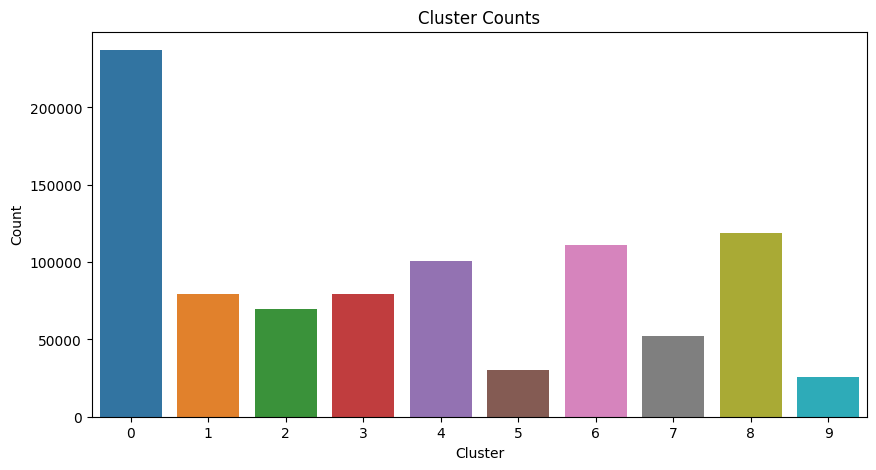

In [43]:

plt.figure(figsize=(10, 5))
sns.countplot(data=data, x='cluster', order=sorted(data['cluster'].unique()), palette='tab10')
plt.title('Cluster Counts')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()


cluster,0,1,2,3,4,5,6,7,8,9
cat3_slug,,,,,,,,,,
apartment-rent,31.0,0.0,9.5,12.2,10.9,0.0,15.4,0.0,21.1,0.0
apartment-sell,43.1,0.0,7.3,10.3,12.9,0.0,14.4,0.0,11.9,0.0
house-villa-rent,10.8,0.0,21.0,13.2,22.3,0.0,7.6,0.0,25.1,0.1
house-villa-sell,27.0,0.0,10.6,10.4,19.5,0.0,21.3,0.0,11.1,0.1
industry-agriculture-business-rent,0.0,39.2,0.1,0.0,0.0,10.7,0.4,13.9,0.0,35.7
industry-agriculture-business-sell,0.0,23.5,0.1,0.0,0.0,7.9,0.3,4.4,0.0,63.8
office-rent,15.7,0.0,8.1,9.7,8.7,0.0,20.4,0.0,37.4,0.1
office-sell,23.8,0.0,7.5,5.0,10.2,0.0,24.3,0.0,29.2,0.0
plot-old,0.0,66.8,0.0,0.0,0.0,17.1,0.0,0.5,0.0,15.6


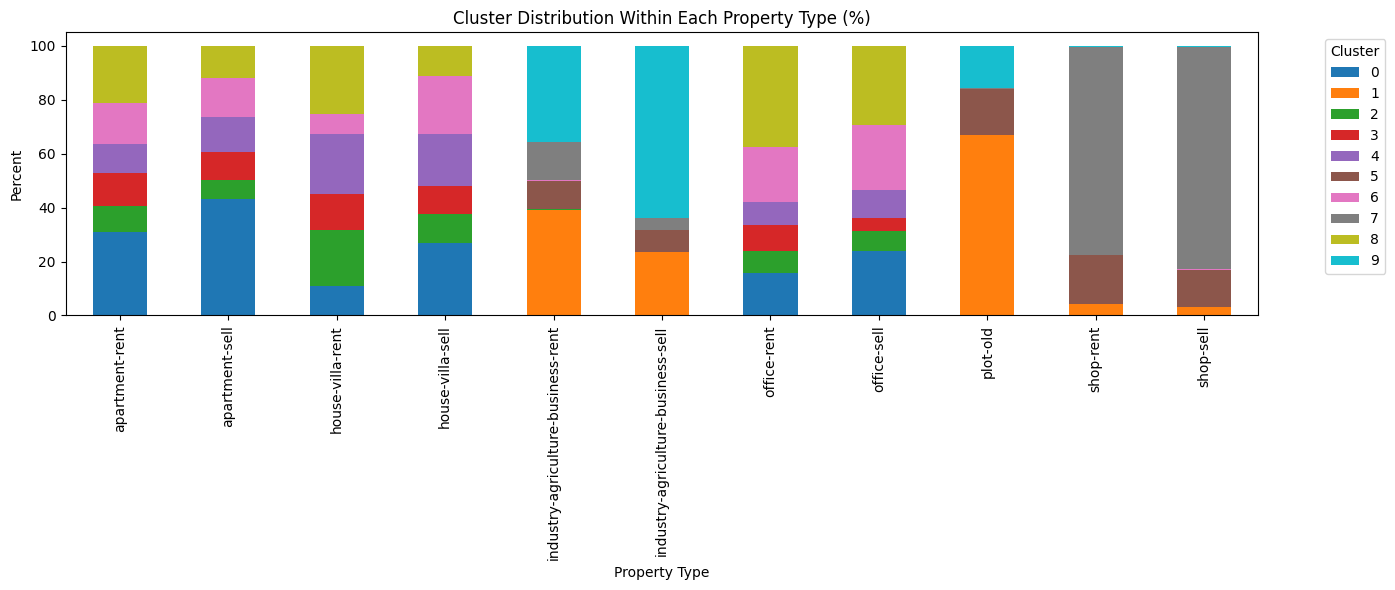

In [44]:

cat_cluster_percent = pd.crosstab(
    data['cat3_slug'],
    data['cluster'],
    normalize='index'
) * 100

cat_cluster_percent = cat_cluster_percent.round(2)
display(cat_cluster_percent)

cat_cluster_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 6),
    colormap='tab10'
)
plt.title('Cluster Distribution Within Each Property Type (%)')
plt.xlabel('Property Type')
plt.ylabel('Percent')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



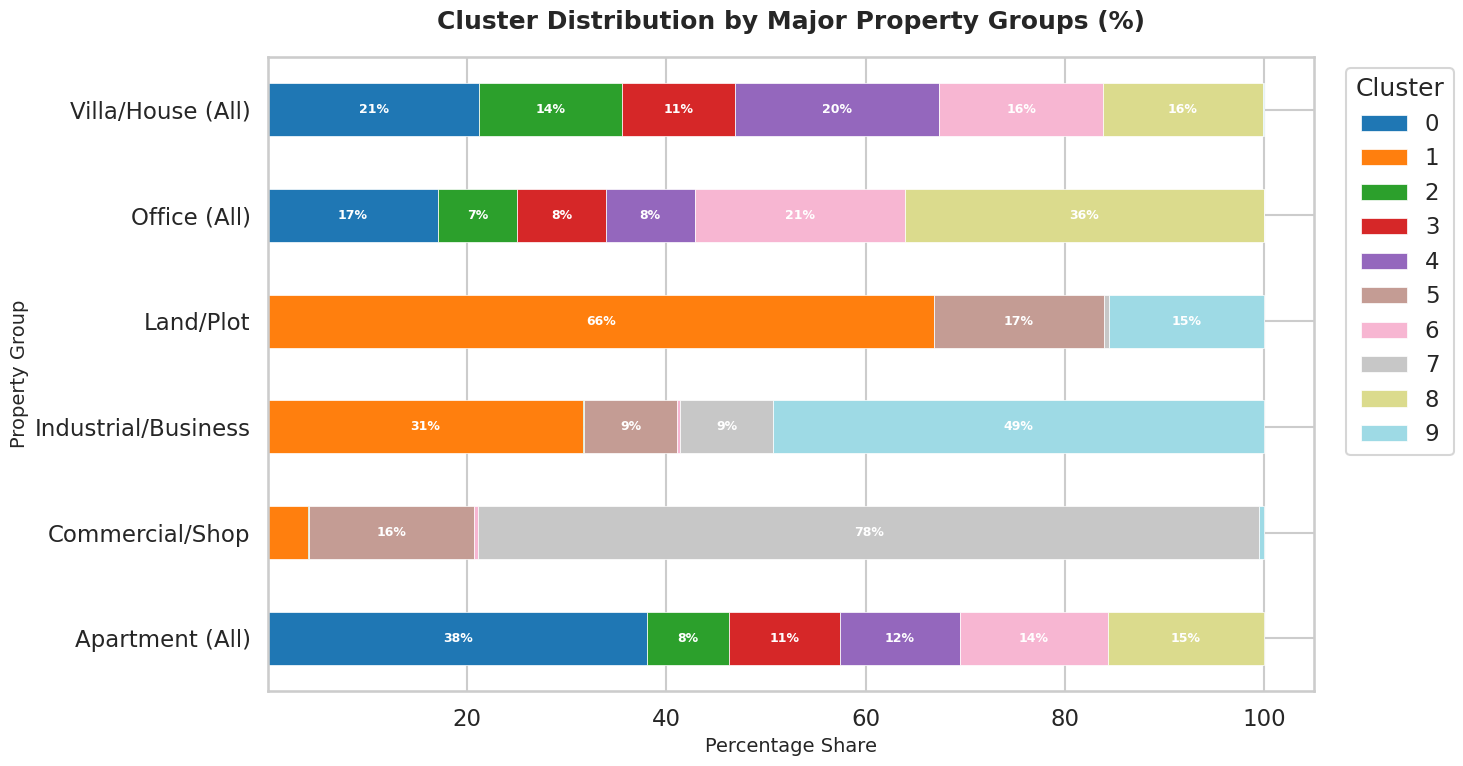

cluster,0,1,2,3,4,5,6,7,8,9
main_property_group,,,,,,,,,,
Apartment (All),38.1,0.0,8.2,11.1,12.0,0.0,14.8,0.0,15.7,0.0
Commercial/Shop,0.0,4.0,0.1,0.0,0.0,16.6,0.4,78.4,0.0,0.5
Industrial/Business,0.0,31.6,0.1,0.0,0.0,9.3,0.3,9.3,0.0,49.3
Land/Plot,0.0,66.8,0.0,0.0,0.0,17.1,0.0,0.5,0.0,15.6
Office (All),17.0,0.0,8.0,8.9,9.0,0.0,21.1,0.0,36.0,0.1
Villa/House (All),21.2,0.0,14.3,11.4,20.5,0.0,16.4,0.0,16.1,0.1


In [35]:
category_map = {
    'apartment-sell': 'Apartment (All)',
    'apartment-rent': 'Apartment (All)',
    
    'house-villa-sell': 'Villa/House (All)',
    'house-villa-rent': 'Villa/House (All)',
    
    'office-sell': 'Office (All)',
    'office-rent': 'Office (All)',
    
    'shop-sell': 'Commercial/Shop',
    'shop-rent': 'Commercial/Shop',
    
    'plot-old': 'Land/Plot',
    
    'industry-agriculture-business-sell': 'Industrial/Business',
    'industry-agriculture-business-rent': 'Industrial/Business'
}

data['main_property_group'] = data['cat3_slug'].map(category_map).fillna('Others')

group_cluster_percent = pd.crosstab(
    data['main_property_group'],
    data['cluster'],
    normalize='index'
) * 100

import matplotlib.pyplot as plt

ax = group_cluster_percent.plot(
    kind='barh', 
    stacked=True,
    figsize=(15, 8),
    colormap='tab20', 
    edgecolor='white',
    linewidth=0.5
)

plt.title('Cluster Distribution by Major Property Groups (%)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Percentage Share', fontsize=14)
plt.ylabel('Property Group', fontsize=14)
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

for p in ax.patches:
    width = p.get_width()
    if width > 5: 
        x, y = p.get_xy()
        ax.text(x + width/2, y + p.get_height()/2, f'{int(width)}%', 
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

display(group_cluster_percent.round(1))


In this stage, the real estate market data were clustered using the KMeans algorithm into 10 groups to uncover the underlying structure of the market. The results showed that the clusters were mainly separated by property type, price per square meter, and the scale of the property.

The clustering results show that the market is not uniform and can be divided into a few clear business segments.

 Cluster 0 is the main mass-market residential segment, dominated by apartments and some villas/offices. It represents the largest share of listings and can be seen as the core of the everyday housing market.
    Cluster 1 is mainly a land and development segment, with a strong concentration of plots and industrial/business properties. This cluster is more relevant for long-term investment and redevelopment rather than end-user housing.
    Clusters 2, 3, and 4 are mostly mid-sized residential segments, with a mix of apartments and villas. These clusters likely reflect different levels of family housing demand across standard and slightly better-quality neighborhoods.
    Cluster 6 stands out as a high-value premium segment, with a stronger presence of offices, apartments, and villa sales. This cluster appears to capture more expensive and strategically located properties.
    Cluster 7 is clearly the commercial cluster, dominated by shops and commercial listings. It reflects a specialized business-oriented market rather than residential demand.
    Cluster 8 is mainly an office-driven small-unit segment, with a notable mix of office and apartment rentals. This suggests a practical, smaller-scale urban investment market.
    Cluster 9 is largely an industrial and large-scale asset segment, dominated by industrial/business listings and land. It represents a very different market from the residential core.

Overall, this clustering was useful for exploratory market analysis and helped reveal the general patterns in the data. However, for a more precise interpretation, it is recommended that clustering be performed separately for groups such as apartments, houses/villas, and land in the next step.

In [ ]:
# price and UTM Plotly

fig = px.scatter(
    data,
    x='utm_x',
    y='utm_y',
    color=data['cluster'].astype(str),
    size='log_unified_price',
    symbol=data['cluster'].astype(str),
    hover_data={
        'cluster': True,
        'cat3_slug': True,
        'unified_price_imputed_all': ':.0f',
        'utm_x': ':.1f',
        'utm_y': ':.1f'
    },
    labels={
        'utm_x': 'UTM X',
        'utm_y': 'UTM Y',
        'color': 'Cluster',
        'size': 'Log Price',
        'symbol': 'Cluster'
    },
    title='Property Clusters on UTM Coordinates by Price',
    opacity=0.75
)

fig.update_layout(
    width=1000,
    height=700,
    legend_title_text='Cluster'
)

fig.show()




In the previous stage, the real estate data was cleaned, missing and abnormal values for property size and price were imputed, geographic coordinates were transformed to UTM, and clustering features were prepared. Then, K-Means was applied to identify hidden market segments, and the resulting clusters were analyzed based on price, size, location, and property type.
section two - Choosing the Optimal Number of Clusters for K-Means


section two

In [ ]:


k_values = list(range(1, 21))
wcss = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_processed)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker='o')
plt.xticks(k_values)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Choosing k')
plt.grid(True, alpha=0.3)
plt.show()




To choose the optimal number of clusters, K-Means was run for k=1 to k=20, and the Within-Cluster Sum of Squares (WCSS) was calculated for each value. As expected, WCSS decreases as k increases, because adding more clusters always reduces within-cluster variance. Therefore, the goal is not to find the minimum WCSS, but to identify the point where the rate of decrease starts to slow down significantly. This point, known as the elbow, represents a reasonable trade-off between model complexity and clustering compactness. If the elbow is not clearly visible, this may indicate that the dataset contains overlapping submarkets, mixed property types, or non-spherical cluster structures. In such cases, elbow analysis should be combined with domain interpretation and, if needed, alternative criteria such as silhouette score or segmented clustering by property type.
The elbow plot shows that the WCSS drops sharply up to about k = 5 or k = 6, and after that the decrease becomes noticeably slower. Therefore, k = 5 or k = 6 is a more reasonable choice.


In [ ]:

silhouette_scores = []
K_range = range(2, 11) 

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_processed)
    score = silhouette_score(X_processed, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o', color='red')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for Optimal k')
plt.grid(True)
plt.show()




 The Silhouette Score shows how well the clusters are separated and how compact they are internally. A higher value means better clustering quality. A value close to 1 indicates well-separated clusters, a value near 0 means points lie on cluster boundaries, and a negative value suggests that some observations may be assigned to the wrong cluster. Therefore, the value of k with the highest Silhouette Score is usually considered the better choice for the number of clusters.




section three

In [ ]:
#Preparing the Features for DBSCAN

db_data = df_final.copy()

db_data = db_data[['utm_x', 'utm_y', 'unified_price_imputed_all']].copy()

db_data['unified_price_imputed_all'] = pd.to_numeric(db_data['unified_price_imputed_all'], errors='coerce')
db_data['log_unified_price'] = np.log1p(db_data['unified_price_imputed_all'])

db_data = db_data.dropna(subset=['utm_x', 'utm_y', 'log_unified_price']).copy()

X_db = db_data[['utm_x', 'utm_y', 'log_unified_price']]

scaler = RobustScaler()
X_db_scaled = scaler.fit_transform(X_db)

dbscan = DBSCAN(eps=0.30, min_samples=25)
db_labels = dbscan.fit_predict(X_db_scaled)

db_data['db_cluster'] = db_labels

print(db_data['db_cluster'].value_counts().sort_index())
print("Number of clusters:", len(set(db_labels)) - (1 if -1 in db_labels else 0))
print("Noise points:", (db_labels == -1).sum())


In [ ]:
# Hyperparameter Search for Meaningful 3 Clusters

results = []

for eps in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    for min_samples in [10, 15, 20, 25, 30]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_db_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()

        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise
        })

results_df = pd.DataFrame(results)
results_df.sort_values(['n_clusters', 'n_noise']).head(20)


In [ ]:
# Final DBSCAN Model
dbscan = DBSCAN(eps=0.35, min_samples=20)

db_labels = dbscan.fit_predict(X_db_scaled)
db_data['db_cluster'] = db_labels

print("Cluster counts:")
print(db_data['db_cluster'].value_counts().sort_index())

n_clusters_final = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_final = (db_labels == -1).sum()

print("Number of clusters:", n_clusters_final)
print("Number of noise points:", n_noise_final)


In [ ]:
# Interactive Plot with Price Information

fig = px.scatter(
    db_data,
    x='utm_x',
    y='utm_y',
    color=db_data['db_cluster'].astype(str),
    size='log_unified_price',
    hover_data={
        'db_cluster': True,
        'unified_price_imputed_all': ':.0f',
        'utm_x': ':.1f',
        'utm_y': ':.1f'
    },
    labels={
        'utm_x': 'UTM X',
        'utm_y': 'UTM Y',
        'color': 'DBSCAN Cluster',
        'size': 'Log Price'
    },
    title='DBSCAN Clustering Using UTM Coordinates and Convertible Price',
    opacity=0.75
)

fig.update_layout(
    width=1000,
    height=700,
    legend_title_text='Cluster'
)

fig.show()


DBSCAN works based on point density and has two main hyperparameters: eps and min_samples. The eps parameter defines the radius within which neighboring points are searched. If eps is too small, many points fail to find enough neighbors and are labeled as noise. On the other hand, if eps is too large, separate clusters may merge together, reducing the number of detected clusters. The min_samples parameter specifies the minimum number of points required to form a dense region. If this value is small, the model forms clusters more easily, and even sparse regions may be identified as clusters. If min_samples is increased, cluster formation becomes more difficult and the number of noise points usually increases. Therefore, the final choice of these parameters should produce clusters that are both interpretable and not overwhelmed by excessive noise.